# Lab 2: Waves in Homogeneous Media
All work and answers can be completed in the Jupyter notebook.  
[Shift]-[Enter] can be used to evaluate cells.  
Put two spaces at the end of a line in markdown cells for new lines.  
Math entry can be done between $\$$ signs e.g. $\eta = {a\over b}$ for in-line equations, or between $\$\$$ for separate-line equations e.g. $$\eta = {a\over b}$$

**Section:**

B02

**Group Number:**

8

**Student Names**

Diego Carrara

**Student Numbers:**

30197278

In [2]:
# Sample code to create a 3D animation

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Example 3D animation
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
# set axes limits 
ax.set(xlim=[-1,1], ylim=[-1,1], zlim=[-1,1], xlabel='x',ylabel='y',zlabel='z',
       xticks=[-1,0,1], yticks=[-1,0,1], zticks=[-1,0,1])

# sample functions of time
t = np.linspace(0,100,101)
x = np.cos(np.pi/50 * t)
y = np.sin(np.pi/50 * t)
z = np.sin(np.pi/10 * t)

#plot vector and individual components for t=0
q = ax.quiver(0,0,0,x[0],y[0],z[0],color='k', arrow_length_ratio=0.1)
qx = ax.quiver(0,0,0,x[0],0,0,color='r', arrow_length_ratio=0.1)
qy = ax.quiver(x[0],0,0,0,y[0],0,color='b', arrow_length_ratio=0.1)
qz = ax.quiver(x[0],y[0],0,0,0,z[0],color='g', arrow_length_ratio=0.1)

#update function, called every frame of the animation
def update(frame):
    ax.cla() # clear previous plot info on the axis, but need to re-do labels/ticks
    ax.set(xlim=[-1,1], ylim=[-1,1], zlim=[-1,1], xlabel='x',ylabel='y',zlabel='z',
       xticks=[-1,0,1], yticks=[-1,0,1], zticks=[-1,0,1])

    #note that frame is being used as an index here
    q = ax.quiver(0,0,0,x[frame],y[frame],z[frame],color='k', arrow_length_ratio=0.1)
    qx = ax.quiver(0,0,0,x[frame],0,0,color='r', arrow_length_ratio=0.1)
    qy = ax.quiver(x[frame],0,0,0,y[frame],0,color='b', arrow_length_ratio=0.1)
    qz = ax.quiver(x[frame],y[frame],0,0,0,z[frame],color='g', arrow_length_ratio=0.1)
    return (q, qx, qy, qz)
    
# frames = number of time steps
# interval = ms between successive frames
ani = animation.FuncAnimation(fig=fig, func=update ,frames=t.size, interval=100)
# close the static plot as we want to focus on the animation
plt.close()
HTML(ani.to_html5_video())


## 3.1 Uniform Plane Wave Visualization

In [3]:
# Params
e0 = 8.85E-12
u0 = 4*np.pi*(10**-7)

frq = 3E9

w = 3E9*2*np.pi

sigma = 0
er = 1
ur = 1

e = e0*er
u = u0*ur

p = sigma/(w*e)

print(p)

a = w*np.sqrt((e*u/2)*(np.sqrt((p**2)+1)-1))
b = w*np.sqrt((e*u/2)*(np.sqrt((p**2)+1)+1))

n = np.sqrt(u/e)*(1/np.pow((1+p**2), 0.25))
thetan = np.arctan(p)/2

print(a)
print(b)
print(n)
print(thetan)

E0=1


zmm = np.linspace(0,300,100)
z = zmm/1000

t = np.linspace(0,0.000000001,100)

Ex = E0*np.exp(-a*z)*np.cos(-b*z)
Hy = (E0/n)*np.exp(-a*z)*np.cos((-b*z)-thetan)

0.0
0.0
62.86047963655232
376.8194372611951
0.0


### 1. Plot the electric and magnetic fields as a function of z at t= 0 in 3D.

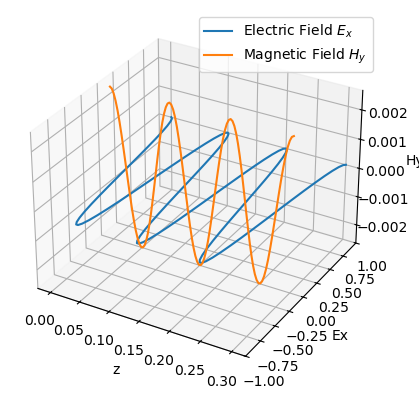

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot Electric Field (offset in y for clarity)
ax.plot(z, Ex, np.zeros_like(z), label='Electric Field $E_x$')

# Plot Magnetic Field (offset in y for clarity)
ax.plot(z, np.zeros_like(z), Hy, label='Magnetic Field $H_y$')

Exmax = np.max(np.abs(Ex))
Hymax = np.max(np.abs(Hy))
ax.set_ylim(-Exmax, Exmax)
ax.set_zlim(-Hymax, Hymax)

# Labels
ax.set_xlabel('z')
ax.set_ylabel('Ex')
ax.set_zlabel('Hy')

ax.legend()
plt.show()

### 2. Plot the electric and magnetic fields as a function of time at z= 0 in 2D

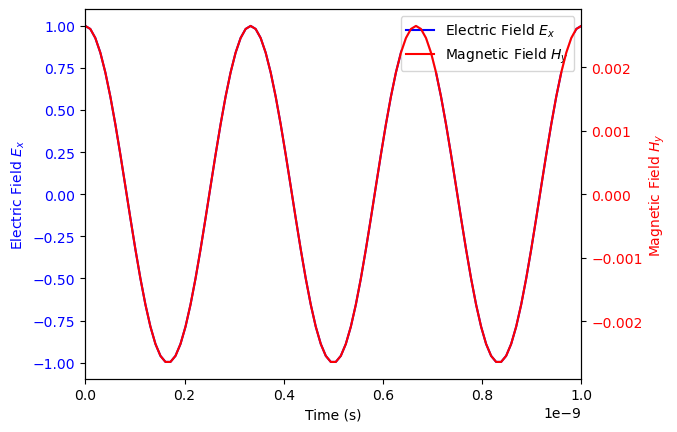

In [5]:
Ex = E0*np.cos(w*t)
Hy = (E0/n)*np.cos((w*t)-thetan)

fig, ax1 = plt.subplots()

ax1.plot(t, Ex, 'b', label='Electric Field $E_x$')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Electric Field $E_x$', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create second y-axis for Hy
ax2 = ax1.twinx()
ax2.plot(t, Hy, 'r', label='Magnetic Field $H_y$')
ax2.set_ylabel('Magnetic Field $H_y$', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Optionally add legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

ax1.set_xlim(0, 1e-9)
plt.show()

### 3. Plot the magnitude of the electric and magnetic field phasors in 3D.

### 4. Generate an animation of the fields for 0 ≤t≤1 ns in 3D.

### 5. Wave traveling in +z-direction in free space at 3 GHz.

### 6. Wave traveling in +z-direction in free space at 1.5 GHz

### 7. Wave traveling in +z-direction in a homogeneous medium with εr = 4,µr = 1, and σ= 0.1 S/m at 3 GHz.

### 8. Wave traveling in the -z-direction and E-field in the +x-direction in free space.

### 9. The sum of a forward-traveling wave with magnitude 1 and phase 0, and a backward-traveling wave with magnitude 0.5 and phase π/4 where both are traveling in free space and both have E-field oriented in the +x- direction.

### 10. What impact does increasing the permittivity have on the wavelength?

### 11. How does decreasing the frequency impact the wavelength?

### 12. What impact does increasing the permittivity have on the magnetic field strength?

### 13. How far does the wave travel before it undergoes 1$Np$ of attenuation when εr = 4 and σ= 0.1 S/m.

### 14. Describe the behavior of the wave resulting from the sum of forward and backward traveling waves over time?

## 3.2 Half-Wavelength Dipole Antenna


In [6]:
# Params
e0 = 8.85E-12
u0 = 4*np.pi*(10**-7)

frq = 3E9

w = 3E9*2*np.pi

sigma = 0
er = 1
ur = 1

e = e0*er
u = u0*ur

p = sigma/(w*e)

print(p)

a = w*np.sqrt((e*u/2)*(np.sqrt((p**2)+1)-1))
b = w*np.sqrt((e*u/2)*(np.sqrt((p**2)+1)+1))

n = np.sqrt(u/e)*(1/np.pow((1+p**2), 0.25))
thetan = np.arctan(p)/2

print(a)
print(b)
print(n)
print(thetan)

E0=1

x = np.linspace(0.1,2,100)
y = np.linspace(-1,1,100)
z = np.linspace(-1,1,100)

X, Y, Z = np.meshgrid(x, y, z)

r = np.sqrt(np.pow(X,2)+np.pow(Y,2)+np.pow(Z,2))
theta = np.arccos(Z/r)
phi = np.arctan2(Y, X)

t = np.linspace(0,0.000000001,100)

I0 = 1

E = 1j*60*I0*(np.exp(-1j*b*r)/r)*np.cos(0.5*np.pi*np.cos(theta))/np.sin(theta)

Ex = np.cos(theta)*np.cos(phi)*E
Ey = np.cos(theta)*np.sin(phi)*E
Ez = -np.sin(phi)*E

0.0
0.0
62.86047963655232
376.8194372611951
0.0


### 15. Plot magnitude of the time-domain E-field (all components) in xy and xz planes in region near the antenna

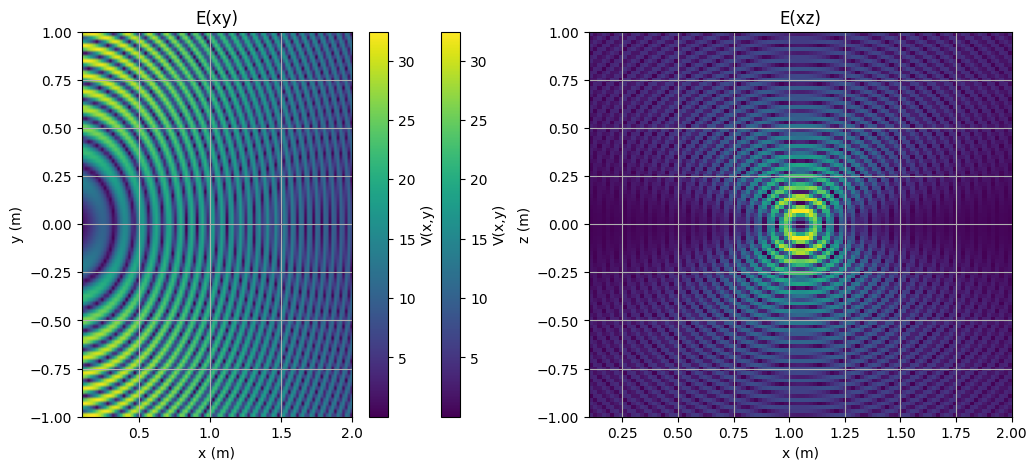

In [7]:
from mpl_toolkits.mplot3d import Axes3D

ME = np.real(np.sqrt(np.pow(Ex,2)+np.pow(Ey,2)+np.pow(Ez,2)))

MExy = ME[:, :, 0]
MExz = ME[:, 0, :]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(MExy, extent=[0.1, 2, -1, 1], origin='lower', cmap='viridis', aspect='auto')
axs[0].set_title('E(xy)')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].grid(True)
fig.colorbar(im0, ax=axs[0], label='V(x,y)')

axs[0].set_xlim(0.1, 2)  
axs[0].set_ylim(-1, 1)    


im1 = axs[1].imshow(MExz, extent=[0.1, 2, -1, 1], origin='lower', cmap='viridis', aspect='auto')
axs[1].set_title('E(xz)')
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('z (m)')
axs[1].grid(True)
fig.colorbar(im0, ax=axs[0], label='V(x,y)')

axs[1].set_xlim(0.1, 2)  # limits x-axis from 0 to 0.5
axs[1].set_ylim(-1, 1)    # limits y-axis from 0 to 2

plt.show()

### 16. Using these plots and code similar to part 3.1 generate animations of the fields in the xy and xz planes.  

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --------------------------
# Parameters
# --------------------------
e0 = 8.85E-12
u0 = 4*np.pi*(10**-7)
frq = 3E9
w = 2*np.pi*frq

sigma = 0
er = 1
ur = 1

e = e0*er
u = u0*ur

p = sigma/(w*e)
a = w*np.sqrt((e*u/2)*(np.sqrt((p**2)+1)-1))
b = w*np.sqrt((e*u/2)*(np.sqrt((p**2)+1)+1))

n = np.sqrt(u/e)*(1/np.power((1+p**2), 0.25))
thetan = np.arctan(p)/2

E0 = 1
I0 = 1

# --------------------------
# Grid setup
# --------------------------
x = np.linspace(0.1, 2, 200)
y = np.linspace(-1, 1, 200)
z = np.linspace(-1, 1, 200)

X_xy, Y = np.meshgrid(x, y)   # xy plane, z=0
X_xz, Z = np.meshgrid(x, z)   # xz plane, y=0

# --------------------------
# Time array
# --------------------------
t = np.linspace(0, 1e-9, 100)

# --------------------------
# Field functions
# --------------------------
def E_field(X, Y, Z, t_frame):
    # Compute r, theta, phi
    r = np.sqrt(X**2 + Y**2 + Z**2)
    theta = np.arccos(np.clip(Z/r, -1, 1))  # clip to avoid NaNs
    phi = np.arctan2(Y, X)

    # Far-field E magnitude
    E = 1j*60*I0*(np.exp(-1j*b*r)/r) * np.cos(0.5*np.pi*np.cos(theta))/np.sin(theta)

    # Components
    Ex = np.real(np.cos(theta)*np.cos(phi)*E*np.exp(1j*w*t_frame))
    Ey = np.real(np.cos(theta)*np.sin(phi)*E*np.exp(1j*w*t_frame))
    Ez = np.real(-np.sin(theta)*E*np.exp(1j*w*t_frame))

    # Total magnitude
    Etot = np.sqrt(Ex**2 + Ey**2 + Ez**2)
    return Etot

# --------------------------
# Initial plots
# --------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

c1 = ax1.imshow(E_field(X_xy, Y, 0, t[0]), extent=[0,2,-1,1],
                origin='lower', cmap='viridis', aspect='auto')
ax1.set_title('E(xy)')
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
fig.colorbar(c1, ax=ax1, label='|E|')

c2 = ax2.imshow(E_field(X_xz, 0, Z, t[0]), extent=[0,2,-1,1],
                origin='lower', cmap='viridis', aspect='auto')
ax2.set_title('E(xz)')
ax2.set_xlabel('x (m)')
ax2.set_ylabel('z (m)')
fig.colorbar(c2, ax=ax2, label='|E|')

# --------------------------
# Animation update
# --------------------------
def update(frame):
    c1.set_data(E_field(X_xy, Y, 0, t[frame]))
    c2.set_data(E_field(X_xz, 0, Z, t[frame]))
    return c1, c2

ani = animation.FuncAnimation(fig, update, frames=len(t), interval=50, blit=True)
plt.close()
HTML(ani.to_html5_video())


### 17. Generate a plot further from the antenna (e.g. 2m ≤x ≤4m).  

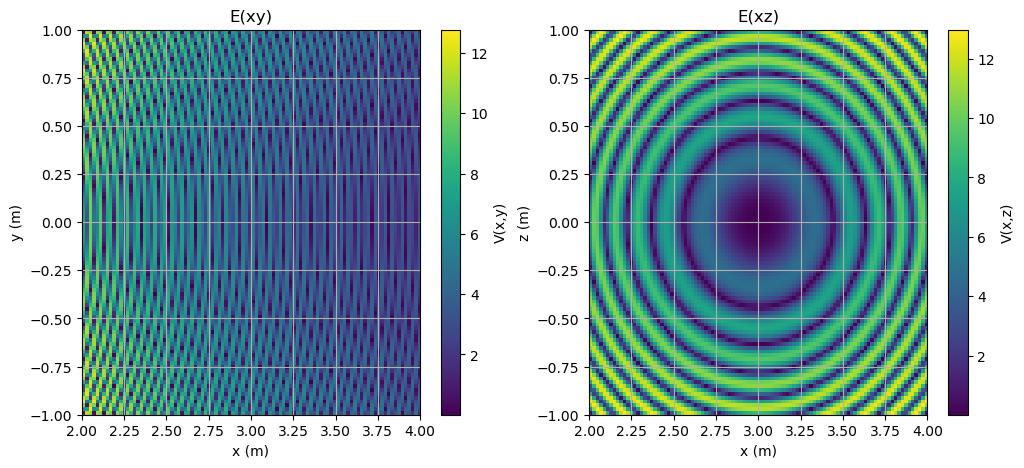

In [61]:
x = np.linspace(2,4,100)
y = np.linspace(-1,1,100)
z = np.linspace(-1,1,100)

X, Y, Z = np.meshgrid(x, y, z)

r = np.sqrt(np.pow(X,2)+np.pow(Y,2)+np.pow(Z,2))
theta = np.arccos(Z/r)
phi = np.arctan2(Y, X)

t = np.linspace(0,0.000000001,100)

I0 = 1

E = 1j*60*I0*(np.exp(-1j*b*r)/r)*np.cos(0.5*np.pi*np.cos(theta))/np.sin(theta)

Ex = np.cos(theta)*np.cos(phi)*E
Ey = np.cos(theta)*np.sin(phi)*E
Ez = -np.sin(phi)*E

ME = np.real(np.sqrt(np.pow(Ex,2)+np.pow(Ey,2)+np.pow(Ez,2)))

MExy = ME[:, :, 0]
MExz = ME[:, 0, :]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(MExy, extent=[2, 4, -1, 1], origin='lower', cmap='viridis', aspect='auto')
axs[0].set_title('E(xy)')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].grid(True)
fig.colorbar(im0, ax=axs[0], label='V(x,y)')

axs[0].set_xlim(2, 4)  
axs[0].set_ylim(-1, 1)    


im1 = axs[1].imshow(MExz, extent=[2, 4, -1, 1], origin='lower', cmap='viridis', aspect='auto')
axs[1].set_title('E(xz)')
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('z (m)')
axs[1].grid(True)
fig.colorbar(im1, ax=axs[1], label='V(x,z)')

axs[1].set_xlim(2, 4)  # limits x-axis from 0 to 0.5
axs[1].set_ylim(-1, 1)    # limits y-axis from 0 to 2

plt.show()

### 18. Finally, generate an animation of the fields very far away from the dipole in the xy plane (e.g. 100m≤x≤102m,−1m≤y≤1m). 

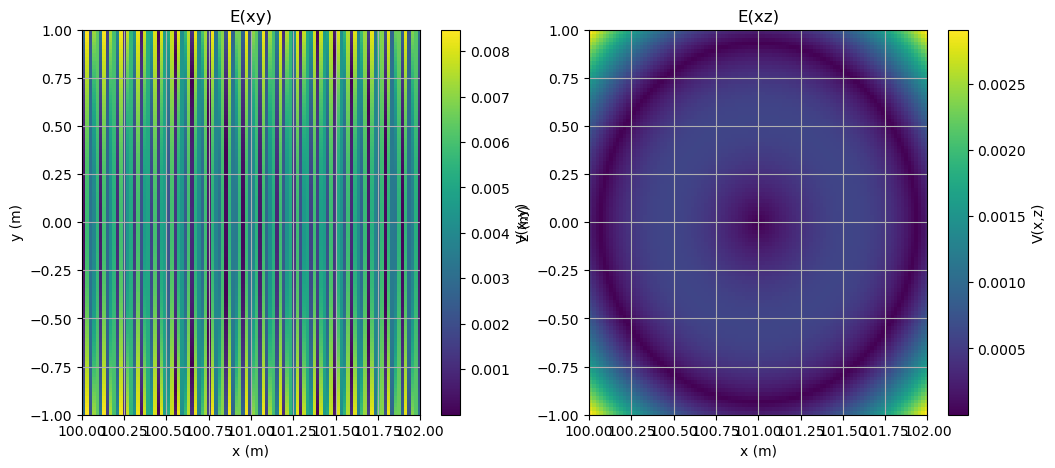

In [64]:
x = np.linspace(100,102,100)
y = np.linspace(-1,1,100)
z = np.linspace(-1,1,100)

X, Y, Z = np.meshgrid(x, y, z)

r = np.sqrt(np.pow(X,2)+np.pow(Y,2)+np.pow(Z,2))
theta = np.arccos(Z/r)
phi = np.arctan2(Y, X)

t = np.linspace(0,0.000000001,100)

I0 = 1

E = 1j*60*I0*(np.exp(-1j*b*r)/r)*np.cos(0.5*np.pi*np.cos(theta))/np.sin(theta)

Ex = np.cos(theta)*np.cos(phi)*E
Ey = np.cos(theta)*np.sin(phi)*E
Ez = -np.sin(phi)*E

ME = np.real(np.sqrt(np.pow(Ex,2)+np.pow(Ey,2)+np.pow(Ez,2)))

MExy = ME[:, :, 0]
MExz = ME[:, 0, :]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(MExy, extent=[100, 102, -1, 1], origin='lower', cmap='viridis', aspect='auto')
axs[0].set_title('E(xy)')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].grid(True)
fig.colorbar(im0, ax=axs[0], label='V(x,y)')

axs[0].set_xlim(100, 102)  # limits x-axis
axs[0].set_ylim(-1, 1)    # limits y-axis


im1 = axs[1].imshow(MExz, extent=[100, 102, -1, 1], origin='lower', cmap='viridis', aspect='auto')
axs[1].set_title('E(xz)')
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('z (m)')
axs[1].grid(True)
fig.colorbar(im1, ax=axs[1], label='V(x,z)')

axs[1].set_xlim(100, 102)  # limits x-axis from 0 to 0.5
axs[1].set_ylim(-1, 1)    # limits y-axis from 0 to 2

plt.show()

### 19. How does the E-field strength vary in the ϕ direction in the xy-plane?

The E-field magnitude is relatively constant in the $\phi$ direction as the waves propagate radially and their peaks are in phase at a constant radius.

### 20. How does the E-field strength vary as the fields move farther from the antenna?

The magnitude of the electric field decreases gradually as the waves propagate away from the antenna, which is modelled by the attenuation constant, $\alpha$.

### 21. Relative to the alignment of the dipole, in which direction is the E-field the weakest?

The E-field is weakest directly in line with the dipole antenna, in the +x and -x directions.

### 22. Compare the behavior of the wave generated by the dipole antenna to a UPW at: 1) 0 ≤z≤2 m, 2) 2 m ≤z≤4 m, and 3) 100 m ≤z≤102 m.